In [1]:
from utils import MedicalDataset, evaluate_model, train_transform, draw_img
from scipy.ndimage import center_of_mass
import torch
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [15]:
def scan_masks_sizes(segmentations):
    x_diff, y_diff = [], []
    max_x_dist = max_x_dist_idx = max_y_dist = max_y_dist_idx = 0
    curr_idx = -1

    for batch in range(segmentations.shape[0]):
        scanned = _scan_mask(segmentations[batch, :, :, :])
        curr_idx += 1
        
        if not scanned:
            continue

        x_diff.append(scanned[1] - scanned[0])
        y_diff.append(scanned[3] - scanned[2])

        if max_x_dist < x_diff[-1]:
            max_x_dist = x_diff[-1]
            max_x_dist_idx = curr_idx

        if max_y_dist < y_diff[-1]:
            max_y_dist = y_diff[-1]
            max_y_dist_idx = curr_idx

    return np.array(x_diff), np.array(y_diff), max_x_dist_idx, max_y_dist_idx

def delete_images_without_cow(x, y):
    keep = np.any(x[:, :, :, 5:] != 0, axis=(1, 2, 3))
    return x[keep], y[keep]

def _scan_mask(seg):
    mask = np.where(seg > 0)
    min_x = mask[1].min()
    max_x = mask[1].max()
    min_y = mask[0].min()
    max_y = mask[0].max()
    return min_x, max_x, min_y, max_y

def get_centroids(segmentations):
    labels = np.ones_like(segmentations).cumsum(axis=0)
    indices = np.arange(1, segmentations.shape[0] + 1)
    return center_of_mass(segmentations > 0, labels, indices)

def fixed_size_center_crop(data, HEIGHT, WIDTH, HEIGHT_HALF, WIDTH_HALF):
    centroids = get_centroids(data[:, :, :, 5:])

    for i, centroid in enumerate(centroids):
        y = round(centroid[1])
        x = round(centroid[2])

        cropped = data[i, y - HEIGHT_HALF : y + HEIGHT_HALF, x - WIDTH_HALF : x + WIDTH_HALF, :]

In [7]:
train_folder = Path('C:/Users/dawid/OneDrive/Pulpit/aneurysm classifier/data/train')
test_folder = Path('C:/Users/dawid/OneDrive/Pulpit/aneurysm classifier/data/test')

In [8]:
x_train = np.load(os.path.join(train_folder, 'train_images.npy'))
y_train = np.load(os.path.join(train_folder, 'train_labels.npy'))
x_test = np.load(os.path.join(test_folder, 'test_images.npy'))
y_test = np.load(os.path.join(test_folder, 'test_labels.npy'))

In [9]:
x_train, y_train = delete_images_without_cow(x_train, y_train)

(81, 148, 107, 146)


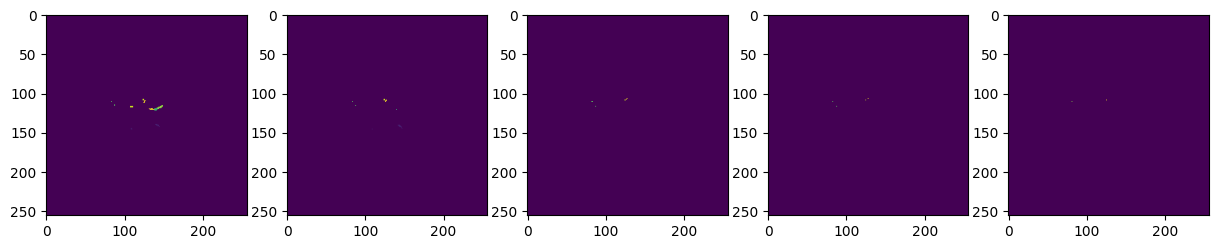

In [10]:
ret = _scan_mask(x_test[0, :, :, 5:])
print(ret)

fig, axes = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    axes[i].imshow(x_test[0, :, :, i + 5])

plt.show()

In [11]:
x_train.shape

(361, 256, 256, 10)

In [12]:
x_diff, y_diff, x_idx, y_idx = scan_masks_sizes(x_train[:, :, :, 5:])
xp_cut = x_diff[x_diff < np.percentile(x_diff, 98)].max()
yp_cut = y_diff[y_diff < np.percentile(y_diff, 98)].max()

print(f'Max\nX: {x_diff.max()}, Y: {y_diff.max()}')
print(f'Percetiles\nX: {xp_cut}, Y: {yp_cut}')

Max
X: 102, Y: 80
Percetiles
X: 92, Y: 55


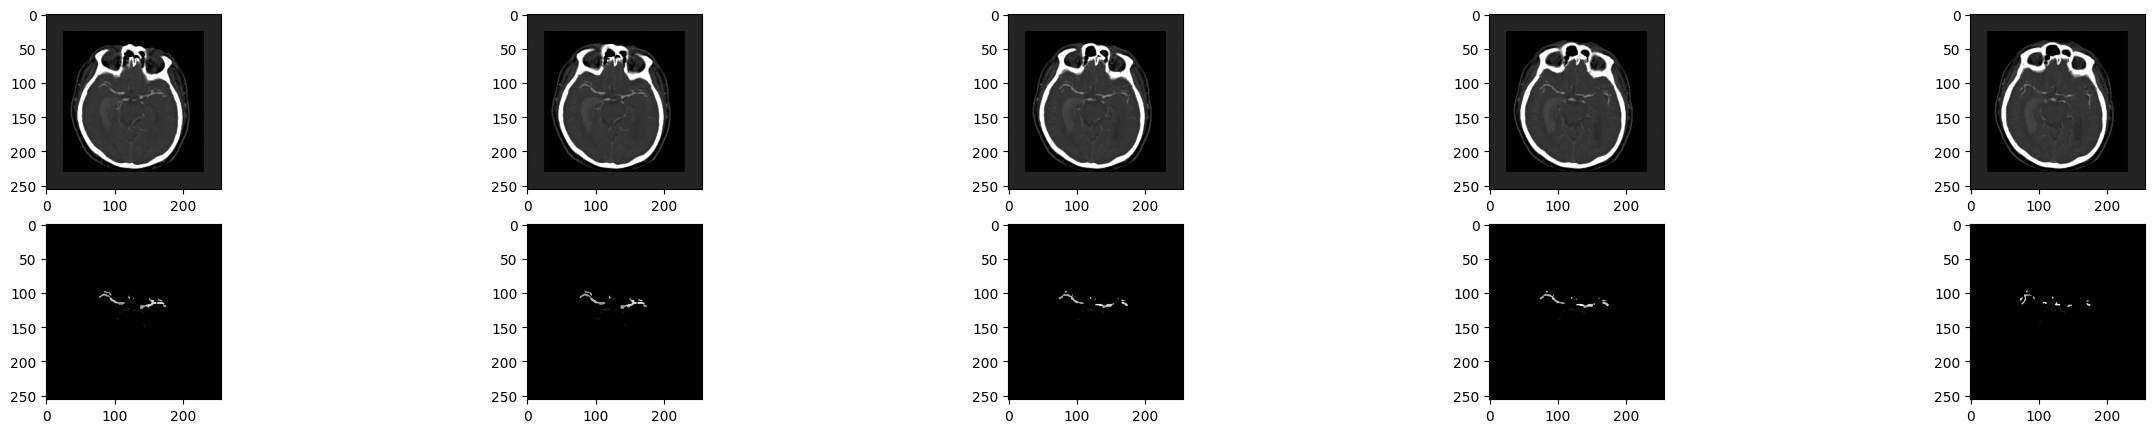

102 52
(73, 175, 97, 149)


In [14]:
draw_img(x_train[x_idx])
ret = _scan_mask(x_train[x_idx, :, :, 5:])
print(ret[1] - ret[0], ret[3] - ret[2])
print(ret)

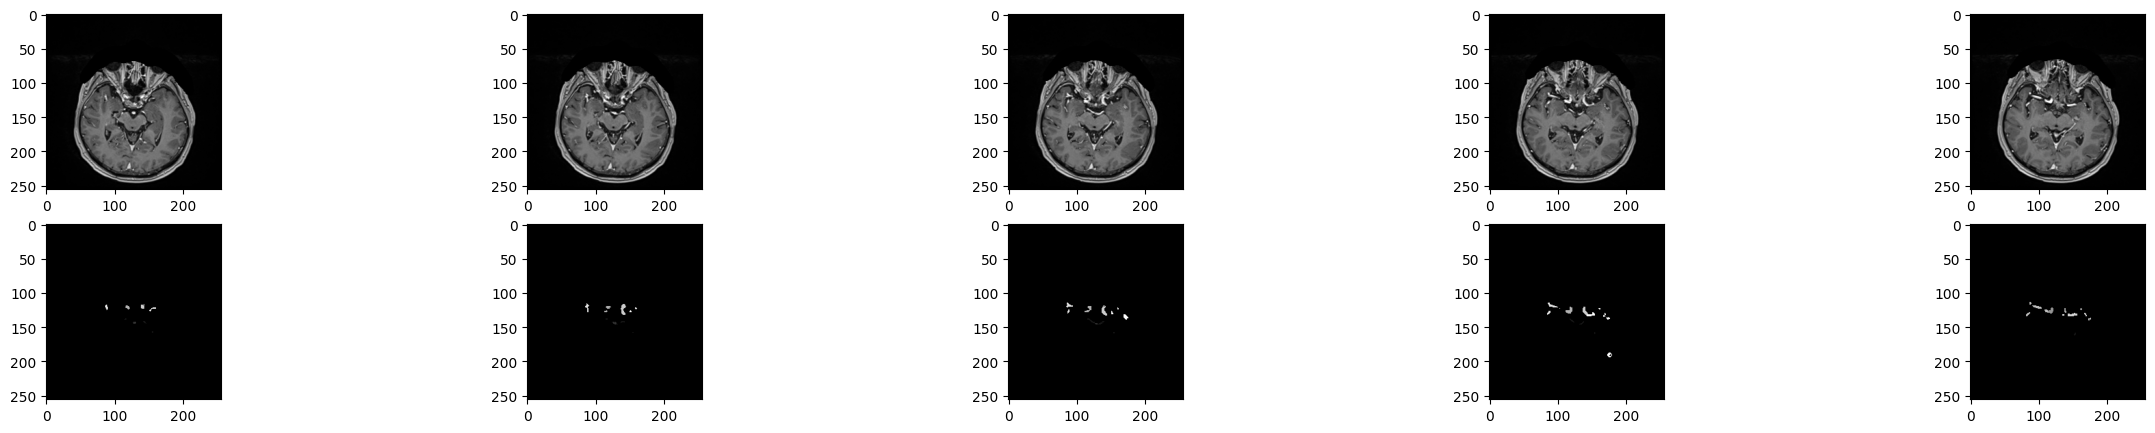

97 80
(82, 179, 114, 194)


In [8]:
draw_img(x_train[y_idx])
ret = _scan_mask(x_train[y_idx, :, :, 5:])
print(ret[1] - ret[0], ret[3] - ret[2])
print(ret)

In [13]:
WIDTH = 96
HEIGHT = 64
WIDTH_HALF = WIDTH // 2
HEIGHT_HALF = HEIGHT // 2

In [16]:
fixed_size_center_crop(x_train, HEIGHT, WIDTH, HEIGHT_HALF, WIDTH_HALF)